# VAE Vocoder

In [1]:
# ! pip install torch==1.7.1+cu101 torchvision==0.8.2+cu101 torchaudio==0.7.2  -f https://download.pytorch.org/whl/torch_stable.html
# ! pip install numpy==1.17.5 matplotlib==3.3.3 tqdm==4.54.0

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from typing import Union
from math import log, pi, sqrt
from IPython.display import display, Audio
from torch.distributions.normal import Normal
import numpy as np
from collections import OrderedDict

import os

device = torch.device("cpu")
if torch.cuda.is_available():
    print('GPU found! 🎉')
    device = torch.device("cuda")

# Autoregressive Flow (theoretical recap)

## What do we want to obtain?

Consider transformations of random variable $z^{(0)} \sim \mathcal{N}(0, I)$: 
$$z^{(0)} \rightarrow z^{(1)} \rightarrow \dots \rightarrow z^{(n)} \rightarrow x.$$

Each transformation has the form: 
$$ 
z^{(k)} = f^{(k)}(z^{(k-1)}) = z^{k-1} \cdot \sigma^{(k)} + \mu^{(k)},
$$ 
where $\mu^{(k)}_t = \mu(z_{<t}^{(k-1)}; \theta_k)$ and $\sigma^{(k)}_t = \sigma(z_{<t}^{(k-1)}; \theta_k)$ – are shifting and scaling variables modeled by a Gaussian WaveNet. 

It is easy to deduce that the whole transformation $f^{(k)} \circ \dots \circ f^{(2)} \circ f^{(1)}$ can be represented as $f^{(\mathrm{total})}(z) = z \cdot \sigma^{(\mathrm{total})} + \mu^{(\mathrm{total})}$, where
$$\sigma^{(\mathrm{total})} = \prod_{k=1}^n \sigma^{(k)}, ~ ~ ~ \mu^{(\mathrm{total})} = \sum_{k=1}^n \mu^{(k)} \prod_{j > k}^n \sigma^{(j)} $$

$\mu^{(\mathrm{total})}$ and $\sigma^{(\mathrm{total})}$ we will need in the future for $p(x | z)$ estimation.

## Helpful notes

[Jacobian matrix and determinant](https://en.wikipedia.org/wiki/Jacobian_matrix_and_determinant#Jacobian_determinant):

$
\mathbf J = \begin{bmatrix}
  \dfrac{\partial \mathbf{f}}{\partial x_1} & \cdots & \dfrac{\partial \mathbf{f}}{\partial x_n}
\end{bmatrix}
= \begin{bmatrix}
  \nabla^{\mathrm T} f_1 \\  
  \vdots \\
  \nabla^{\mathrm T} f_m   
\end{bmatrix}
= \begin{bmatrix}
    \dfrac{\partial f_1}{\partial x_1} & \cdots & \dfrac{\partial f_1}{\partial x_n}\\
    \vdots                             & \ddots & \vdots\\
    \dfrac{\partial f_m}{\partial x_1} & \cdots & \dfrac{\partial f_m}{\partial x_n}
\end{bmatrix}
$

### Lemma:

Suppose $z \in \mathbb{R}^n$ an n-dimensional random variable with joint density $p$. If $x = f(z)$, where $f$ is a bijective, differentiable function, then $x$ has density $p_x(x)$:

$$
p_x(\mathbf x) = 
p_z(\mathbf z) \cdot \left| \det\frac{d\mathbf{z}}{d\mathbf{x}} \right| = 
p_z(\mathbf z) \cdot \left| \det\frac{df^{-1}(\mathbf{x})}{d\mathbf{x}} \right| 
$$, where $\dfrac{df^{-1}(\mathbf{x})}{d\mathbf{x}}$ is a **Jacobian** of the inverse of $f: f^{-1}$

## Why does the determinant appear?

Because in multiple dimensions, we do not just need a “scale factor along one axis.” We need the factor that tells us how the **entire small volume element** changes.

Take a tiny volume $dV_z$ around a point $z$. After the transformation $x = f(z)$, this tiny volume becomes approximately

$$
d\mathbf{V}_x \approx \left|\det \frac{d\mathbf{x}}{d\mathbf{z}}\right| d\mathbf{V}_z
$$

This means that the Jacobian determinant tells us the **local volume scaling** of the transformation.

Now use conservation of probability mass:

$$
p_z(\mathbf{z}) d\mathbf{V}_z = p_x(\mathbf{x}) d\mathbf{V}_x
$$

Substitute the volume relation:

$$
p_x(\mathbf{x}) = p_z(\mathbf{z})\frac{d\mathbf{V}_z}{d\mathbf{V}_x}
= p_z(\mathbf{z})\frac{1}{\left|\det \frac{d\mathbf{x}}{d\mathbf{z}}\right|}
$$



Equivalently,

$$
p_x(\mathbf{x}) = p_z(\mathbf{z})\left|\det \frac{d\mathbf{z}}{d\mathbf{x}}\right| = p_z(f^{-1}(\mathbf{x})) {\left| \det\dfrac{df^{-1}(\mathbf{x})}{d\mathbf{x}} \right|}
$$

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/96/Jacobian_determinant_and_distortion.svg/1920px-Jacobian_determinant_and_distortion.svg.png" width="80%">

Physical interpretation of this image is that $\left| \det\frac{d\mathbf{z}}{d\mathbf{x}} \right|$ shows us how the new probability density $p_x(\mathbf x)$ changes from $p_z(\mathbf z)$, how it stretches.

In logarithmic scale we have:
$$
\log p_x(\mathbf x) = \log p_z(f^{-1}(\mathbf{x})) + \log{\left| \det\dfrac{df^{-1}(\mathbf{x})}{d\mathbf{x}} \right|}
$$

so we want to maximize this logarithmic likelihood, we can compute it numerically knowing function $f$ and initial distribution $z$

# Masked Autoregressive Flow - MAF

During sampling process of **MAF** network we use previous $x_{1:i-1}$ states to predict $\mu_i$ and $\alpha_i$ to sample $x_i$ as $x_i = u_i \cdot \exp(\alpha_i) + \mu_i$, we can do it in **autoregressive** manner.

$$p(x) = \prod_{i}p(x_i|x_{1:i-1})$$

$$p(x_i|x_{1:i-1}) = \mathcal{N}(x_i | \mu_i, (\exp{\alpha_i})^2)$$
where 

$$
\mu_i = f_{\mu_i}(x_{1:i-1}), \qquad
\alpha_i = f_{\alpha_i}(x_{1:i-1}), \qquad
\sigma_i = \exp(\alpha_i)
$$
and the latent noise is

$$u_i \sim \mathcal{N}(0, 1)$$

So the forward transformation is

$$
x_i = \mu_i + \sigma_i u_i
= \mu_i + \exp(\alpha_i) u_i
$$

## Sampling in MAF

<img src="./maf.PNG" width="80%">

To generate a sample, we must compute $x_1, x_2, \dots, x_D$ in order:

$$
x_1 \rightarrow x_2 \rightarrow \dots \rightarrow x_D
$$

This is because $\mu_i$ and $\alpha_i$ depend on the already generated values $x_{1:i-1}$.
\
\
\
\
**sampling is autoregressive and therefore sequential**



## Likelihood evaluation / training in MAF

<img src="./maf_inv.PNG" width="80%">

During training process of **MAF**, we restore $u_i, i=1...D$ given the full vector $x$.
We can recover the noise variables as

$$
u_i = \frac{x_i - \mu_i}{\sigma_i}
= \frac{x_i - \mu_i}{\exp(\alpha_i)}
$$

with

$$
\mu_i = f_{\mu_i}(x_{1:i-1}), \qquad
\alpha_i = f_{\alpha_i}(x_{1:i-1})
$$

The important point is that here the network conditions on $(x_{1:i-1})$, and the full $x$ is already known.
Because of masking, all $\mu_i$ and $\alpha_i$ can be computed in **one parallel forward pass**.

So for MAF:

* **sampling is slow** because it is sequential
* **training / likelihood computation is fast** because it can be parallelized

# Inversed Autoregressive Flow - IAF

<img src="./iaf.PNG" width="80%">

An **Inverse Autoregressive Flow** uses the same affine transformation,

$$
x_i = \mu_i + \sigma_i u_i
$$

but now the parameters depend on the **previous noise dimensions** rather than the previous data dimensions:

$$
\mu_i = f_{\mu_i}(u_{1:i-1}), \qquad
\alpha_i = f_{\alpha_i}(u_{1:i-1}), \qquad
\sigma_i = \exp(\alpha_i)
$$

So the transformation becomes

$$
x_i = \mu_i + \exp(\alpha_i) u_i
$$

## Sampling

In IAF, we first sample the whole noise vector

$$
u \sim \mathcal{N}(0, I)
$$

Since the entire $u$ is already known, the masked network can compute all $\mu_i$ and $\alpha_i$ from $u$ in one pass.
That means we can obtain all $x_i$ **in parallel**.

So **sampling in IAF is fast**.

## Likelihood evaluation / training in IAF

Here must be a fancy picture, but it's not...

The problem is that we have achieved non-autoregressiveness on inference, but on training step we use following equation to restore noise $u$ fro signal $x$:

$$
u_i = \frac{x_i - \mu_i}{\exp{\alpha_i}}
$$, similar to one in **MAF** inference, but now we need to predict $\mu_i$ and $\sigma_i$ from  $u_{1:i-1}$, so we need previous states of noise $u$ to restore the next one. That is the problem of **IAF**.



If we are given $x$ and want to recover $u$, we use

$$
u_i = \frac{x_i - \mu_i}{\exp(\alpha_i)}
$$

However, now $\mu_i$ and $\alpha_i$ depend on $u_{1:i-1}$, not on $x_{1:i-1}$.
That creates a problem:

* to compute $u_i$, we need $u_{1:i-1}$
* so we must recover $u_1, u_2, \dots, u_D$ **one by one**

Therefore, for IAF:

* **sampling is fast**
* **exact likelihood evaluation / inversion is slow**

This is the opposite tradeoff of MAF.

## Intuition

MAF and IAF use almost the same formula, but they condition on different variables:

* **MAF** conditions on previous **data** values $x_{1:i-1}$
* **IAF** conditions on previous **noise** values $u_{1:i-1}$

That one change flips which direction is easy:

* In **MAF**, going from $x \to u$ is easy, so likelihood computation is efficient.
* In **IAF**, going from $u \to x$ is easy, so sampling is efficient.

---

## One-line summary

* **MAF**: good for **density estimation**, because likelihood is cheap.
* **IAF**: good for **fast sampling**, which is why it is often used in **VAEs** for approximate posteriors.

---


## How to compute Jacobian for IAF?

During training we compute $z$ as:

$$
z_i = \frac{x_i - \mu(z_{<t}^{(k-1)}; \theta_k)}{\sigma(z_{<t}^{(k-1)}; \theta_k)} = \frac{x_i}{\sigma_i} - \frac{\mu_i}{\sigma_i} \rightarrow \dfrac{d \mathbf{z}_i}{d\mathbf{x}_i} = \dfrac{1}{\sigma_i}
$$

$\mu, \sigma$ have no dependence on the current or latter variables in our sequence, so: 

$$
\dfrac{d \mathbf{z}}{d\mathbf{x}} = \begin{bmatrix}
    \dfrac{1}{\sigma_0} & 0 & \cdots & 0\\
    \dfrac{\partial z_1}{\partial x_0} & \dfrac{1}{\sigma_1} &  \ddots & 0\\
    \vdots & \ddots & \ddots & 0 \\
    \dfrac{\partial z_n}{\partial x_0} & \cdots & \dfrac{\partial z_{n-1}}{\partial x_n} & \dfrac{1}{\sigma_n}
\end{bmatrix}
$$

Knowing that the determinant of a triangular matrix is the product of its diagonals, this gives us our final result for the log determinant which is incredibly simple to compute:

$$
\log{\left| \det\dfrac{df^{-1}(\mathbf{x})}{d\mathbf{x}} \right|} = - \sum_{i=0}^{n} \log{\sigma_i(z)}
$$

# [Parallel WaveNet](https://arxiv.org/pdf/1711.10433.pdf)

While the convolutional structure of WaveNet allows for rapid parallel training, sample generation
remains inherently sequential and therefore slow, as it is for all autoregressive models which use
ancestral sampling. We therefore seek an alternative architecture that will allow for rapid, parallel
generation.

<img src="./parallel_wavenet1.PNG" width="100%">

<img src="./parallel_wavenet2.PNG" width="80%">

IAF сэмплит быстро, поэтому во время трейна мы тупо сэмплим и все, градиент имеется, потом берем и эту генерацию сравниваем с генерацией полученной из учителя, у которого зафрижены веса, но он быстро нам дает xi+1 для каждого xi

Yes, WaveNet is everywhere. 


We can build MAF and IAF with any architecture, 
but WaveNet declared oneself as simple yet powerfull architecture. 
We will use WaveNet with conditioning on mel spectrograms, 
because we are building a vocoder.

In [3]:
from modules import CausalConv, ResBlock

For WaveNet it doesn't matter what it is used for: MAF or IAF - it all depends on our interpretation of the input and output variables.

## Teacher WaveNet

In [4]:
class WaveNet(nn.Module):
    def __init__(self, 
                 out_channels=2,
                 num_blocks=2,
                 num_layers=10,
                 residual_channels=128,
                 gate_channels=256,
                 skip_channels=128,
                 kernel_size=2,
                 cin_channels=80,
                 upsample_scales=[16, 16]):
        super(WaveNet, self). __init__()

        self.front_conv = nn.Sequential(
            CausalConv(1, residual_channels, 32),
            nn.ReLU()
        )

        self.res_blocks = nn.ModuleList()
        for b in range(num_blocks):
            for n in range(num_layers):
                self.res_blocks.append(ResBlock(
                    in_channels=residual_channels,
                    out_channels=gate_channels,
                    skip_channels=skip_channels,
                    kernel_size=kernel_size,
                    dilation=2 ** n,
                    cin_channels=cin_channels))

        self.final_conv = nn.Sequential(
            nn.ReLU(),
            CausalConv(skip_channels, skip_channels, 1),
            nn.ReLU(),
            CausalConv(skip_channels, out_channels, 1)
        )
        
        self.upsample_conv = nn.ModuleList()
        for s in upsample_scales:
            convt = nn.ConvTranspose2d(1, 1, (3, 2 * s), padding=(1, s // 2), stride=(1, s))
            convt = nn.utils.weight_norm(convt)
            nn.init.kaiming_normal_(convt.weight)
            self.upsample_conv.append(convt)
            self.upsample_conv.append(nn.LeakyReLU(0.4))
    
    def forward(self, x, c):
        # x: input tensor with signal or noise [B, 1, T]
        # c: local conditioning [B, C_mel, T]
        
        c = self.upsample(c)
        out = 0
        
        x = self.front_conv(x)
        
        for block in self.res_blocks:
            x, skip = block(x, c)
            out += skip

        out = self.final_conv(out)
        return out

    def upsample(self, c):
        if self.upsample_conv is not None:
            # B x 1 x C x T'
            c = c.unsqueeze(1)
            for f in self.upsample_conv:
                c = f(c)
            # B x C x T
            c = c.squeeze(1)
        return c

In [5]:
net = WaveNet().to(device).eval()

with torch.no_grad():
    z = torch.FloatTensor(5, 1, 4096).normal_().to(device)
    c = torch.FloatTensor(5, 80, 4096 // 256).zero_().to(device)
    assert list(net(z, c).size()) == [5, 2, 4096]

/opt/miniconda3/envs/ML/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


📝 Notes: 
1. WaveNet outputs tensor `output` of size `[B, 2, T]`, where `output[:, 0, :]` is $\mu$ and `output[:, 1, :]` is $\log \sigma$. We model logarithms of $\sigma$ insead of $\sigma$ for stable gradients. 
2. As we model $\mu(z_{<t}^{(k-1)}; \theta_k)$ and $\sigma(z_{<t}^{(k-1)}; \theta_k)$ – their output we have length `T - 1`. To keep constant length `T` of modelled noise variable we need to pad it on the left side (with zero).
3. $\mu^{(\mathrm{total})}$ and $\sigma^{(\mathrm{total})}$ wil have length `T - 1`, because we do not pad distribution parameters.

In [ ]:
class Wavenet_Flow(nn.Module):
    def __init__(self, 
                 out_channels=1, 
                 num_blocks=1, 
                 num_layers=10,
                 front_channels=32, 
                 residual_channels=64, 
                 gate_channels=32, 
                 skip_channels=64,
                 kernel_size=3, 
                 cin_channels=80):
        super(Wavenet_Flow, self). __init__()

        self.num_blocks = num_blocks
        self.num_layers = num_layers
        self.front_channels = front_channels
        self.out_channels = out_channels
        self.gate_channels = gate_channels
        self.residual_channels = residual_channels
        self.skip_channels = skip_channels
        self.cin_channels = cin_channels
        self.kernel_size = kernel_size

        self.front_conv = nn.Sequential(
            CausalConv(1, self.residual_channels, self.front_channels),
            nn.ReLU()
        )
        self.res_blocks = nn.ModuleList()
        self.res_blocks_fast = nn.ModuleList()
        for b in range(self.num_blocks):
            for n in range(self.num_layers):
                self.res_blocks.append(
                    ResBlock(
                        self.residual_channels, 
                        self.gate_channels, 
                        self.skip_channels,
                        self.kernel_size, 
                        dilation=2**n,
                        cin_channels=self.cin_channels
                    )
                )
                
        self.final_conv = nn.Sequential(
            nn.ReLU(),
            CausalConv(self.skip_channels, self.skip_channels, 1),
            nn.ReLU(),
            CausalConv(self.skip_channels, self.out_channels, 1)
        )

    def forward(self, x, c=None):
        x = self.front_conv(x)
        skip = 0
        for i, f in enumerate(self.res_blocks):
            x, s = f(x, c)
            skip += s
        out = self.final_conv(skip)
        return out

class Wavenet_Decoder(nn.Module):
    def __init__(self, 
                 num_blocks_student=[1, 1, 1, 1, 1, 1], 
                 num_layers=10,
                 front_channels=32, 
                 residual_channels=64, 
                 gate_channels=128, 
                 skip_channels=64,
                 kernel_size=3, 
                 cin_channels=80):
        super(Wavenet_Decoder, self).__init__()
        self.num_blocks = num_blocks_student
        self.num_flow = len(self.num_blocks)
        self.num_layers = num_layers

        self.iafs = nn.ModuleList()
        for i in range(self.num_flow):
            self.iafs.append(
                Wavenet_Flow(
                    out_channels=2,
                    num_blocks=self.num_blocks[i], 
                    num_layers=self.num_layers,
                    front_channels=front_channels, 
                    residual_channels=residual_channels,
                    gate_channels=gate_channels, 
                    skip_channels=skip_channels,
                    kernel_size=kernel_size, 
                    cin_channels=cin_channels
                )
            )
    
    def forward(self, z, c_up):
        # z  - noise
        mu_tot, logs_tot = 0., 0.
        for i, iaf in enumerate(self.iafs):
            mu_logs = iaf(z, c_up)
            mu = mu_logs[:, 0:1, :-1] # mu ~ [0 ..... T - 1]
            logs = mu_logs[:, 1:, :-1]
            mu_tot = mu_tot * torch.exp(logs) + mu
            logs_tot = logs_tot + logs
            z = z[:, :, 1:] * torch.exp(logs) + mu # z ~ [z_1(i-1) .... z_T(i-1)]
            # z_res ~ [z_1(i-1) * mu_0(i) .... z_T(i-1) * mu_(T-1)_i]
            z = F.pad(z, pad=(1, 0), mode='constant', value=0) # z ~ 0 + [z_1 .... z_T]
        return z, mu_tot, logs_tot
    
    # Decoder -> x_i, mu(z), sigma(z)
    # z (prior | \theta) = (x_i - mu(z | \theta)) / sigma(z | \theta)

    def generate(self, z, c_up):
        # z  - noise
        x, _, _ = self(z, c_up)
        return x

In [7]:
net = Wavenet_Decoder(
    num_blocks_student=[1, 1, 1, 1, 1, 1],
    num_layers=10
).to(device)

with torch.no_grad():
    z = torch.FloatTensor(3, 1, 4096).normal_().to(device)
    c = torch.FloatTensor(3, 80, 4096).zero_().to(device)
    z_hat, mu, log_sigma = net(z, c)
    assert list(z_hat.size()) == [3, 1, 4096]         # same length as input
    assert list(mu.size()) == [3, 1, 4096 - 1]        # shorter by one sample
    assert list(log_sigma.size()) == [3, 1, 4096 - 1] # shorted by one sample

If you are not familiar with VAE framework, please try to figure it out. For example, please familiarize with this [blog post](https://wiseodd.github.io/techblog/2016/12/10/variational-autoencoder/).


In short, VAE – is just "modification" of AutoEncoder, which consists of encoder and decoder. VAE allows you to sample from data distribution $p(x)$ as $p(x|z)$ via its decoder, where $p(z)$ is simple and known, e.g. $\mathcal{N}(0, I)$. The interesting part is that $p(x | z)$ cannot be optimized with Maximum Likelihood Estimation, because $p(x | z)$ is not tractable. 

But we can maximize Evidence Lower Bound (ELBO) which has a form:

$$\max_{\phi, \theta} \mathbb{E}_{q_{\phi}(z | x)} \log p_{\theta}(x | z) - \mathbb{D}_{KL}(q_{\phi}(z | x) || p(z))$$

where $p_{\theta}(x | z)$ is VAE decoder and $q_{\phi}(z | x)$ is VAE encoder. For more details please read mentioned blog post or any other materials on this theme.

In our case $q_{\phi}(z | x)$ is represented by MAF WaveNet, and $p_{\theta}(x | z)$ – by IAF build with WaveNet stack. To be more precise our decoder $p_{\theta}(x | z)$ is parametrised by the **one-step-ahead prediction** from an IAF.

`generate` method, which accepts mel spectrogram as conditioning tensor. Inside this method random tensor from standart distribution N(0, I) is sampled. This tensor than transformed to tensor from audio distribution via `encoder`. In the cell bellow you will see code for loading pretrained model and mel spectrogram. Listen to result – it should sound okay.



Substitution of our model formulas in $\mathbb{D}_{KL}$ formula gives `loss_kld` in `forward` method as KL divergence:

$$\mathbb{D}_{KL}(q_{\phi}(z | x) || p(z)) = \sum_t \log\frac{1}{\varepsilon} + \frac{1}{2}(\varepsilon^2 - 1 + (\frac{x_t - \mu(x_{<t})}{\sigma(x_{<t})})^2)$$

---

The other term in ELBO formula can be interpreted as reconstruction loss. It can be evaluated by sampling from $p_{\theta}(x | z)$, where $z$ is from $q_{\phi}(z | \hat x)$, $\hat x$ is our ground truth audio. But sampling is not differential operation! We can apply reparametrization trick!

`loss_rec` in `forward` method is a recontruction loss – which is just log likelihood of ground truth sample $x$ in predicted by IAF distribution $p_{\theta}(x | \hat z)$ where $\hat z \sim q_{\phi}(z | \hat x)$.

$$
\log p_{\theta}(x | z) = \log p(z) - \sum_{t=1}^{T} \sum_{i=0}^{N} \log{\sigma_{i,t}} = 
- \dfrac{1}{2} \sum_{i=0}^{N} \left[ \log{2\pi} + \frac{x_{i,t} - \mu(x_{<t}; \phi)}{\sigma(x_{<t})} + \sum_{t=1}^{T}\log{\sigma_{i,t}} \right]
$$

--- 

Vocoders without MLE are still not able to train without auxilary losses. We studied many of them, but STFT-loss is our favourite!

`loss_frame_rec` stands for MSE loss in STFT domain between original audio and its reconstruction.

--- 

We can go even further and calculate STFT loss with random sample from $p_\theta(x | z)$. Conditioning on mel spectrogram allows us to do so.

`loss_frame_prior` stands for MSE loss in STFT domain between original audio and sample from prior.

In [20]:
# Inputs

x = torch.load('data/x.pth')
c = torch.load('data/c.pth')

x = x[:64 * 256]
c = c[:, :64]

x = x.unsqueeze(0).unsqueeze(0).to(device)
c = c.unsqueeze(0).to(device)
print (x.shape, c.shape)


torch.Size([1, 1, 16384]) torch.Size([1, 80, 64])


In [21]:
encoder = WaveNet(
    out_channels=2,
    num_blocks=2,
    num_layers=10,
    residual_channels=128,
    gate_channels=256,
    skip_channels=128,
    kernel_size=2,
    cin_channels=80,
    upsample_scales=[16, 16]
)

decoder = Wavenet_Decoder(
    num_blocks_student=[1, 1, 1, 1, 1, 1],
    num_layers=10
)

log_eps = nn.Parameter(torch.zeros(1))

encoder = encoder.to(device)
decoder = decoder.to(device)
log_eps = log_eps.to(device)

/opt/miniconda3/envs/ML/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


The `forward` method will return the loss. But lets talk more precisly about our architecture and how it was trained.

The encoder of our model $q_{\phi}(z|x)$ is parametrerized by a Gaussian autoregressive WaveNet, which maps the audio $\mathbf{x}$ into the sample length latent representation $\mathbf{z}$. Specifically, the Gaussian WaveNet (if we talk about **real MAF**) models $x_t$ given the previous samples $x_{<t}$ with $x_t ∼ \mathcal{N}(\mu(x_{<t}; \phi), \sigma(x_{<t}; \phi))$, where the mean $\mu(x_{<t}; \phi)$ and log-scale $\log \sigma(x_{<t}; \phi)$ are predicted by WaveNet, respectively.

Our **encoder** posterior is constructed as

$$q_{\phi}(z | x) = \prod_{t} q_{\phi}(z_t | x_{\leq t})$$

where

$$q_{\phi}(z_t | x_{\leq t}) = \mathcal{N}(\frac{x_t - \mu(x_{<t}; \phi)}{\sigma(x_{<t}; \phi)}, \varepsilon)$$

We apply the mean $\mu(x_{<t}; \phi)$ and scale $\sigma(x_{<t})$ for "whitening" the posterior distribution. Also we introduce a trainable scalar $\varepsilon > 0$ to decouple the global variation, which will make optimization process easier.

In [ ]:
# x: audio signal [B, 1, T]
# c: mel spectrogram [B, mel_c, T / HOP_SIZE]

# Encode
# mu_logs = [μ, logσ] used to define the posterior distribution q(z|x).
# mu, logs ~ [B, 1, T-1]
# target x[:, :, 1:] ~ [B, 1, T-1] as well


mu_logs = encoder(x, c)  # -> [B, 2, T]
mu = mu_logs[:, 0:1, :-1]  # μ ~ [0 ..... T - 1]
logs = mu_logs[:, 1:, :-1]  # logσ ~ [0 ..... T - 1]

## Why :-1?

One-step-ahead prediction.
Causal WaveNet on position t can have only past as an available data, and it predicts the next sample -> target is shifted by 1 to the right.

`mu`, `logs` ~ [B, 1, T-1] \
`target` x[:, :, 1:] ~ [B, 1, T-1]

In [11]:
# Base normal distribution
q_0 = Normal(mu.new_zeros(mu.size()), mu.new_ones(mu.size()))


In [12]:
# "Whitening" the posterior. This centers and scales x relative to encoder output.
# We use this as the mean of the posterior.
# We want mean_q to be similar to N(0, 1), ideally mean_q ~ N(0, 1)

mean_q = (x[:, :, 1:] - mu) * torch.exp(-logs)


$$
\exp(-\log \sigma_t) = \frac{1}{\sigma_t}
$$

so we get

$$
{\text{mean}_q}_t = \frac{x_t - \mu_t}{\sigma_t}
$$

where $x_t$ here is actually `x[:, :, 1:]`.

### What this means intuitively

The encoder says:

* here is the local expected value $\mu_t$
* here is the local scale $\sigma_t$

Then

$$
\frac{x_t - \mu_t}{\sigma_t}
$$

is the **standardized residual**, that is, “how much the sample deviates from the predictable part.”

If $\mu_t, \sigma_t$ describe the waveform well, then this residual should look like something close to $\mathcal N(0,1)$.

So `mean_q` here is not “the mean in x-space”.
It is better understood as a **whitened residual**, which the author of the code uses as the center of the posterior over $z$.

<!-- This is an unusual but understandable construction:

$$
q_\phi(z_t \mid x_{\le t}, c) = \mathcal N\left(
\frac{x_t - \mu_t}{\sigma_t}, \varepsilon^2
\right)
$$ -->


In [13]:
# Reparameterization, Sampling from prior

z = q_0.sample() * torch.exp(log_eps) + mean_q
z_prior = q_0.sample()


## Reparameterization trick

This is equivalent to

$$
z_{\text{prior}}  \sim \mathcal N(0,1)
$$

$$
z =  \varepsilon *  z_{\text{prior}} + {\text{mean}_q}
$$

where

$$
\varepsilon = e^{\text{logs}}
$$

So this is the standard VAE reparameterization form:

$$
z = \sigma_q \odot \xi + \mu_q
$$

except that here

* $\mu_q = \text{mean}_q$
* $\sigma_q = \varepsilon$ is a single global scalar.

It is used so that the decoder learns not only to reconstruct from a posterior sample, 
but also to generate something reasonable from the prior.


In [14]:
# First token = 0

z = F.pad(z, pad=(1, 0), mode='constant', value=0)
z_prior = F.pad(z_prior, pad=(1, 0), mode='constant', value=0)
c_up = encoder.upsample(c)


After all the shifts, the length became `T-1`.
Now one zero is added on the left to restore the length back to `T`.


But this is not just restoring the length.
It is also a **causal start token**: the first timestep has no past, so it is given a zero initialization.

In [15]:
# Decode
# x_rec : [B, 1, T] (first time step zero-padded)
# mu_p, log_p : [B, 1, T-1]

x_rec, mu_p, log_p = decoder(z, c_up)
x_prior, _, _ = decoder(z_prior, c_up)



> `z` is taken from the posterior, the decoder builds the reconstruction

> `z_prior` is taken from the prior the decoder generates a “free” sample, but it is still conditioned on mel

In [16]:
def stft(y):
    D = torch.stft(y, n_fft=1024, hop_length=256, win_length=1024, window=torch.hann_window(1024), return_complex=False)
    D = torch.sqrt(D.pow(2).sum(-1) + 1e-10)
    S = 2 * torch.log(torch.clamp(D, 1e-10, float("inf")))
    return D, S

In [18]:
loss_recon = -0.5 * (- log(2.0 * pi) - 2. * log_p - torch.pow(x[:, :, 1:] - mu_p, 2) * torch.exp((-2.0 * log_p)))

/opt/miniconda3/envs/ML/lib/python3.10/site-packages/torch/functional.py:681: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/SpectralOps.cpp:879.)
  return _VF.stft(  # type: ignore[attr-defined]


## Reconstruction loss: what is actually being computed here

Let us rewrite it carefully.

$$
\log p_{\theta}(x | z) = \log p(z; \theta) - \sum_{t=1}^{T} \sum_{i=0}^{N} \log{\sigma_i(\theta)}=

- \dfrac{1}{2} \sum_{i=0}^{N} \left[ \log{2\pi} + \frac{x_{i,t} - \mu_i(x_{<t}; \theta)}{\sigma_i(x_{<t}; \theta)} + \sum_{t=1}^{T}\log{\sigma_i(\theta)} \right]
  $$

$$
\log p(x_t|z,c)=
-\frac{1}{2}
\left[
\log(2\pi) + (x_t-\mu_{p,t})^2 * e^{-2\log \sigma} + 2\log \sigma_{p,t}
\right]
$$

In the code, this is exactly what is written, just in a more awkward form.

Because:

$$
e^{-2\log \sigma} = \sigma^{-2}
$$

So this line is simply the **Gaussian NLL** between the ground truth sample and the parameters predicted by the decoder.

### Intuition

This part tells the decoder:

> “If I give you a latent variable `z` obtained from real audio, then you must produce such a distribution over `x` under which the real waveform has high probability.”

This is exactly the reconstruction term in the ELBO sense.

In [ ]:
loss_kl = 0.5 * (mean_q ** 2 + torch.exp(log_eps) ** 2 - 1) - log_eps

## KL loss: where it comes from

$$
\mathbb{D}_{KL}(q_{\phi}(z | x) || p(z)) = \sum_t \log\frac{1}{\varepsilon} + \frac{1}{2}(\varepsilon^2 - 1 + (\frac{x_t - \mu(x_{<t})}{\sigma(x_{<t})})^2)
$$

Our posterior is:

$$
q(z_t|x)=\mathcal N(\text{mean}_q,\varepsilon^2)
$$

Prior:

$$
p(z_t)=\mathcal N(0,1)
$$

KL between two one-dimensional Gaussians:

$$
\mathbb{D}_{KL}\big(\mathcal N(\mu,\sigma^2)||\mathcal N(0,1)\big) =
\frac12(\mu^2+\sigma^2-1-\log \sigma^2)
$$

Substituting:

* $\mu = \text{mean}_q$
* $\sigma = \varepsilon = e^{\log \varepsilon}$

Then:

$$
D_{KL} =

\frac12(\text{mean}_q^2+ e^{2\log \varepsilon}-1-2\log\varepsilon)
$$

### Intuition for KL here

> It penalizes the posterior for deviating too much from the standard normal prior. In other words, the model should encode in $z$ only what is actually necessary, rather than stuffing the entire waveform into it without any constraint.


`x_prior` - $x (z_\text{prior} ; \theta; c)$

In [ ]:
# For annealing during training:
# slowly increase the weight of KL loss over training to avoid posterior collapse.
# early in training, let model focus on reconstruction; 
# later encourage meaningful latent structure.
global_step = 35000
alpha = 1 / (1 + np.exp(-5e-5 * (global_step - 5e+5))) 

stft_rec, stft_rec_log = stft(x_rec[:, 0, 1:])
stft_truth, stft_truth_log = stft(x[:, 0, 1:])
stft_prior, stft_prior_log = stft(x_prior[:, 0, 1:])

loss_frame_rec = F.mse_loss(stft_rec, stft_truth) + F.mse_loss(stft_rec_log, stft_truth_log)
loss_frame_prior = F.mse_loss(stft_prior, stft_truth) + F.mse_loss(stft_prior_log, stft_truth_log)

## STFT losses

Three signals are used:

* `x_rec` — reconstruction from a posterior sample
* `x` — ground truth
* `x_prior` — sample from the prior

And for each of them, the log-power STFT is computed

---

### Reconstruction spectral loss

```python
loss_frame_rec = F.mse_loss(stft_rec, stft_truth) + F.mse_loss(stft_rec_log, stft_truth_log)
```

This says:

> “The reconstruction should be similar to the target not only sample-by-sample, but also spectrally.”

This is very useful for audio: waveform MSE/NLL by itself often gives poor perceptual quality.

---

### Prior spectral loss

```python
loss_frame_prior = F.mse_loss(stft_prior, stft_truth) + F.mse_loss(stft_prior_log, stft_truth_log)
```

This is even more important conceptually.

Here the model is forced to make sure that even if you take:

$$
z \sim \mathcal N(0,I)
$$

then, conditioned on mel, the result is spectrally close to the target.

### Intuition

This directly pushes the decoder toward good generation **from the prior**, not just reconstruction from the posterior.

And this is very much in the spirit of Parallel WaveNet, where the authors explicitly emphasized that the probabilistic term alone is not enough, and added auxiliary losses on the generated sample, including STFT / power-like loss.

### But this is no longer a “pure ELBO”

In a pure VAE, there does not have to be a loss that directly compares a prior sample to a specific target waveform.


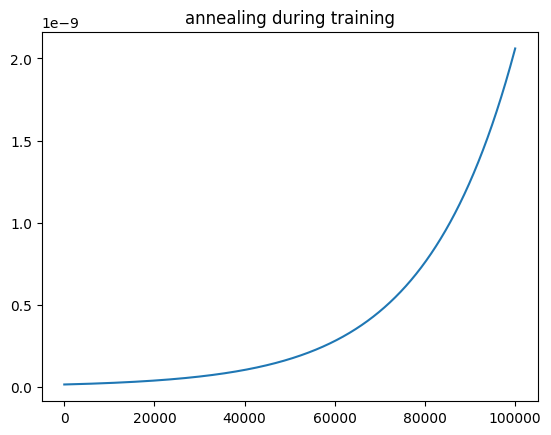

In [19]:
from matplotlib import pyplot as plt
alpha = [1 / (1 + np.exp(-5e-5 * (i - 5e+5))) for i in range(1, 100000)]
plt.plot(alpha)
plt.title("annealing during training")
plt.show()

In [ ]:
class WaveNetVAE(nn.Module):
    def __init__(self):
        super(WaveNetVAE, self).__init__()

        self.encoder = WaveNet(out_channels=2,
                               num_blocks=2,
                               num_layers=10,
                               residual_channels=128,
                               gate_channels=256,
                               skip_channels=128,
                               kernel_size=2,
                               cin_channels=80,
                               upsample_scales=[16, 16])
        self.decoder = Wavenet_Decoder(num_blocks_student=[1, 1, 1, 1, 1, 1],
                                       num_layers=10)
        self.log_eps = nn.Parameter(torch.zeros(1))
    
    @staticmethod
    def stft(y):
        D = torch.stft(y, n_fft=1024, hop_length=256, win_length=1024, window=torch.hann_window(1024), return_complex=False)
        D = torch.sqrt(D.pow(2).sum(-1) + 1e-10)
        S = 2 * torch.log(torch.clamp(D, 1e-10, float("inf")))
        return D, S
    
    def forward(self, x, c):
        # x: audio signal [B, 1, T]
        # c: mel spectrogram [B, mel_c, T / HOP_SIZE]

        # Encode
        # mu_logs = [μ, logσ] used to define the posterior distribution q(z|x).
        # mu, logs ~ [B, 1, T-1]
        # target x[:, :, 1:] ~ [B, 1, T-1] as well

        mu_logs = self.encoder(x, c) # -> [B, 2, T] 
        mu = mu_logs[:, 0:1, :-1] # μ
        logs = mu_logs[:, 1:, :-1] # logσ

        # Base normal distribution
        q_0 = Normal(mu.new_zeros(mu.size()), mu.new_ones(mu.size()))
        
        # "Whitening” the posterior. This centers and scales x relative to encoder output. 
        # We use this as the mean of the posterior.
        # We want mean_q to be similar to N(0, 1), ideally mean_q ~ N(0, 1)
        mean_q = (x[:, :, 1:] - mu) * torch.exp(-logs)

        # Reparameterization, Sampling from prior
        z = q_0.sample() * torch.exp(self.log_eps) + mean_q
        z_prior = q_0.sample()

        # First token = 0
        z = F.pad(z, pad=(1, 0), mode='constant', value=0)
        z_prior = F.pad(z_prior, pad=(1, 0), mode='constant', value=0)
        c_up = self.encoder.upsample(c)

        # Decode
        # x_rec : [B, 1, T] (first time step zero-padded)
        # mu_tot, logs_tot : [B, 1, T-1]
        x_rec, mu_p, log_p = self.decoder(z, c_up)
        x_prior, _, _ = self.decoder(z_prior, c_up)

        loss_recon = -0.5 * (- log(2.0 * pi) - 2. * log_p - torch.pow(x[:, :, 1:] - mu_p, 2) * torch.exp((-2.0 * log_p)))
        loss_kl = 0.5 * (mean_q ** 2 + torch.exp(self.log_eps) ** 2 - 1) - self.log_eps
        
        # For annealing during training:
        # slowly increase the weight of KL loss over training to avoid posterior collapse.
        # early in training, let model focus on reconstruction; 
        # later encourage meaningful latent structure.
        global_step = 35000
        alpha = 1 / (1 + np.exp(-5e-5 * (global_step - 5e+5))) 
        
        stft_rec, stft_rec_log = self.stft(x_rec[:, 0, 1:])
        stft_truth, stft_truth_log = self.stft(x[:, 0, 1:])
        stft_prior, stft_prior_log = self.stft(x_prior[:, 0, 1:])
        
        loss_frame_rec = F.mse_loss(stft_rec, stft_truth) + F.mse_loss(stft_rec_log, stft_truth_log)
        loss_frame_prior = F.mse_loss(stft_prior, stft_truth) + F.mse_loss(stft_prior_log, stft_truth_log)
        
        return  loss_recon.mean() + alpha * loss_kl.mean() + loss_frame_rec + loss_frame_prior

    def generate(self, c):
        # c: mel spectrogram [B, 80, L] where L - number of mel frames
        # outputs: audio [B, 1, L * HOP_SIZE]
        c_up = self.encoder.upsample(c)
        
        q_0 = Normal(torch.zeros(1, 1, c_up.size(2)), torch.ones(1, 1, c_up.size(2)))
        z = q_0.sample()
        
        x_sample, _, _ = self.decoder(z, c_up)
        return x_sample

In [ ]:
def load_checkpoint(model, checkpoint: OrderedDict):
    if 'module' not in list(checkpoint["state_dict"].keys())[0]:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        print("INFO: this model is trained with DataParallel. Creating new state_dict without module...")
        state_dict = checkpoint["state_dict"]
        
        new_state_dict = OrderedDict()
    
        for k, v in state_dict.items():
            name = k[7:]  # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(dict(new_state_dict))

Link to checkpoint: https://disk.yandex.ru/d/Yl2Ie7ZNJRa5HQ

In [ ]:
# saved checkpoint model has following architecture parameters
        
# load checkpoint
ckpt_path = 'checkpoint.pth'
model = WaveNetVAE().eval().to(device)
checkpoint = torch.load(ckpt_path, map_location='cpu')
load_checkpoint(model, checkpoint)

# load original audio and it's mel
x = torch.load('data/x.pth').to(device)
c = torch.load('data/c.pth').to(device)

# generate audio from 
with torch.no_grad():
    x_prior = model.generate(c.unsqueeze(0)).squeeze()

display(Audio(x_prior.cpu(), rate=22050))

/var/folders/ym/qnqcqs_j7fjgf1q8crhq9fj40000gn/T/ipykernel_75053/2814110641.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_locati

INFO: this model is trained with DataParallel. Creating new state_dict without module...


/var/folders/ym/qnqcqs_j7fjgf1q8crhq9fj40000gn/T/ipykernel_75053/2814110641.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load('data/x.pth').to(device)
/var

In [ ]:
x = torch.load('data/x.pth').to(device)
c = torch.load('data/c.pth').to(device)

model = WaveNetVAE().to(device).train()

x = x[:64 * 256]
c = c[:, :64]

model.zero_grad()
loss = model.forward(x.unsqueeze(0).unsqueeze(0), c.unsqueeze(0))
loss.backward()
print(f"Initial loss: {loss.item():.2f}")

checkpoint = torch.load(ckpt_path, map_location='cpu')
load_checkpoint(model, checkpoint)

model.zero_grad()
loss = model.forward(x.unsqueeze(0).unsqueeze(0), c.unsqueeze(0))
loss.backward()
print(f"Optimized loss: {loss.item():.2f}")

/var/folders/ym/qnqcqs_j7fjgf1q8crhq9fj40000gn/T/ipykernel_75053/2513369377.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load('data/x.pth').to(device)
/var/

Initial loss: 1701.98


/var/folders/ym/qnqcqs_j7fjgf1q8crhq9fj40000gn/T/ipykernel_75053/2513369377.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_locat

INFO: this model is trained with DataParallel. Creating new state_dict without module...
Optimized loss: 7.97
